In [1]:
# ============================================================
# CELL 1 — Install Libraries
# ============================================================
!pip install scikit-learn pandas numpy matplotlib joblib xgboost -q

In [2]:
# ============================================================
# CELL 2 — Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
import joblib
import os
import json

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [3]:
# ============================================================
# CELL 3 — Load & Clean Data
# ============================================================
from IPython.display import display

DATA_PATH = "/content/metal_prices_impact.csv"   # ← update if your file name is different

df = pd.read_csv(DATA_PATH)
print("📊 Raw dataset shape:", df.shape)
display(df.head())

# Date parsing & deduplication
df["Date"] = pd.to_datetime(df["Date"])
df = df.drop_duplicates(subset="Date").sort_values("Date").reset_index(drop=True)

# Strip commas and convert Nifty / Sensex to numeric
for col in ["Price_Nifty", "Price_Sensex"]:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

# Keep only required columns
KEEP_COLS = ["Date", "Price_Nifty", "Price_Sensex"]
if "Impact" in df.columns:
    KEEP_COLS.append("Impact")

df = df[KEEP_COLS].copy()
df = df.ffill().bfill()

print("\n✅ Cleaned shape:", df.shape)
print(df.isna().sum())
display(df.head())

📊 Raw dataset shape: (2142, 6)


,Date,Gold Price (INR / 10gms),Silver Price (INR / 1kg),Price_Nifty,Price_Sensex,Impact
0,2018-01-01,NaN,NaN,NaN,33812.75,-0.59
1,2018-01-02,26975.40,35156.11,10442.20,33812.26,-0.54
2,2018-01-03,26854.25,35062.32,10443.20,33793.38,-0.56
3,2018-01-04,26902.19,35047.88,10504.80,33969.64,-0.60
4,2018-01-05,26899.53,35053.12,10558.85,34153.85,-0.55



✅ Cleaned shape: (2142, 4)
Date            0
Price_Nifty     0
Price_Sensex    0
Impact          0
dtype: int64


,Date,Price_Nifty,Price_Sensex,Impact
0,2018-01-01,10442.20,33812.75,-0.59
1,2018-01-02,10442.20,33812.26,-0.54
2,2018-01-03,10443.20,33793.38,-0.56
3,2018-01-04,10504.80,33969.64,-0.60
4,2018-01-05,10558.85,34153.85,-0.55


In [4]:
# ============================================================
# CELL 4 — Feature Engineering
# ============================================================
INDEX_COLS = ["Price_Nifty", "Price_Sensex"]

for col in INDEX_COLS:
    # Lag features
    for lag in [1, 2, 3, 5]:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)

    # Rolling mean and std
    for window in [3, 5, 7, 14]:
        df[f"{col}_MA{window}"]  = df[col].rolling(window).mean()
        df[f"{col}_std{window}"] = df[col].rolling(window).std()

    # Momentum / returns
    df[f"{col}_ret1"] = df[col].pct_change(1)
    df[f"{col}_ret3"] = df[col].pct_change(3)
    df[f"{col}_ret5"] = df[col].pct_change(5)

    # Exponential moving averages
    df[f"{col}_EMA5"]  = df[col].ewm(span=5,  adjust=False).mean()
    df[f"{col}_EMA10"] = df[col].ewm(span=10, adjust=False).mean()

    # Rolling range (volatility proxy)
    df[f"{col}_range5"] = df[col].rolling(5).max() - df[col].rolling(5).min()

# Calendar features
df["day_of_week"]  = df["Date"].dt.dayofweek
df["month"]        = df["Date"].dt.month
df["quarter"]      = df["Date"].dt.quarter
df["week_of_year"] = df["Date"].dt.isocalendar().week.astype(int)

# Cross-index spread (normalised)
df["spread_NS"] = df["Price_Nifty"] - (df["Price_Sensex"] / 3.3)

# Drop NaN rows created by rolling/lag
df = df.dropna().reset_index(drop=True)
print(f"✅ Feature engineering done — {df.shape[1]} columns, {df.shape[0]} rows")
from IPython.display import display
display(df.head())

✅ Feature engineering done — 45 columns, 2129 rows


,Date,Price_Nifty,Price_Sensex,Impact,Price_Nifty_lag1,Price_Nifty_lag2,Price_Nifty_lag3,Price_Nifty_lag5,Price_Nifty_MA3,Price_Nifty_std3,...,Price_Sensex_ret3,Price_Sensex_ret5,Price_Sensex_EMA5,Price_Sensex_EMA10,Price_Sensex_range5,day_of_week,month,quarter,week_of_year,spread_NS
0,2018-01-18,10817.0,35260.29,-0.59,10788.55,10700.45,10741.55,10651.20,10768.666667,60.765828,...,0.011961,0.021934,34943.972357,34688.895307,667.90,3,1,1,3,132.063636
1,2018-01-19,10894.7,35511.58,-0.59,10817.00,10788.55,10700.45,10681.25,10833.416667,54.946209,...,0.021297,0.026572,35133.174904,34838.474342,740.53,4,1,1,3,133.615152
2,2018-01-22,10966.2,35798.01,-1.00,10894.70,10817.00,10788.55,10741.55,10892.633333,74.621467,...,0.020415,0.027394,35354.786603,35012.935371,1026.96,0,1,1,4,118.318182
3,2018-01-23,11083.7,36139.98,-1.00,10966.20,10894.70,10817.00,10700.45,10981.533333,95.428420,...,0.024948,0.039370,35616.517735,35217.852576,1058.16,1,1,1,4,132.190909
4,2018-01-24,11086.0,36161.64,-1.00,11083.70,10966.20,10894.70,10788.55,11045.300000,68.512262,...,0.018306,0.030780,35798.225157,35389.450289,901.35,2,1,1,4,127.927273


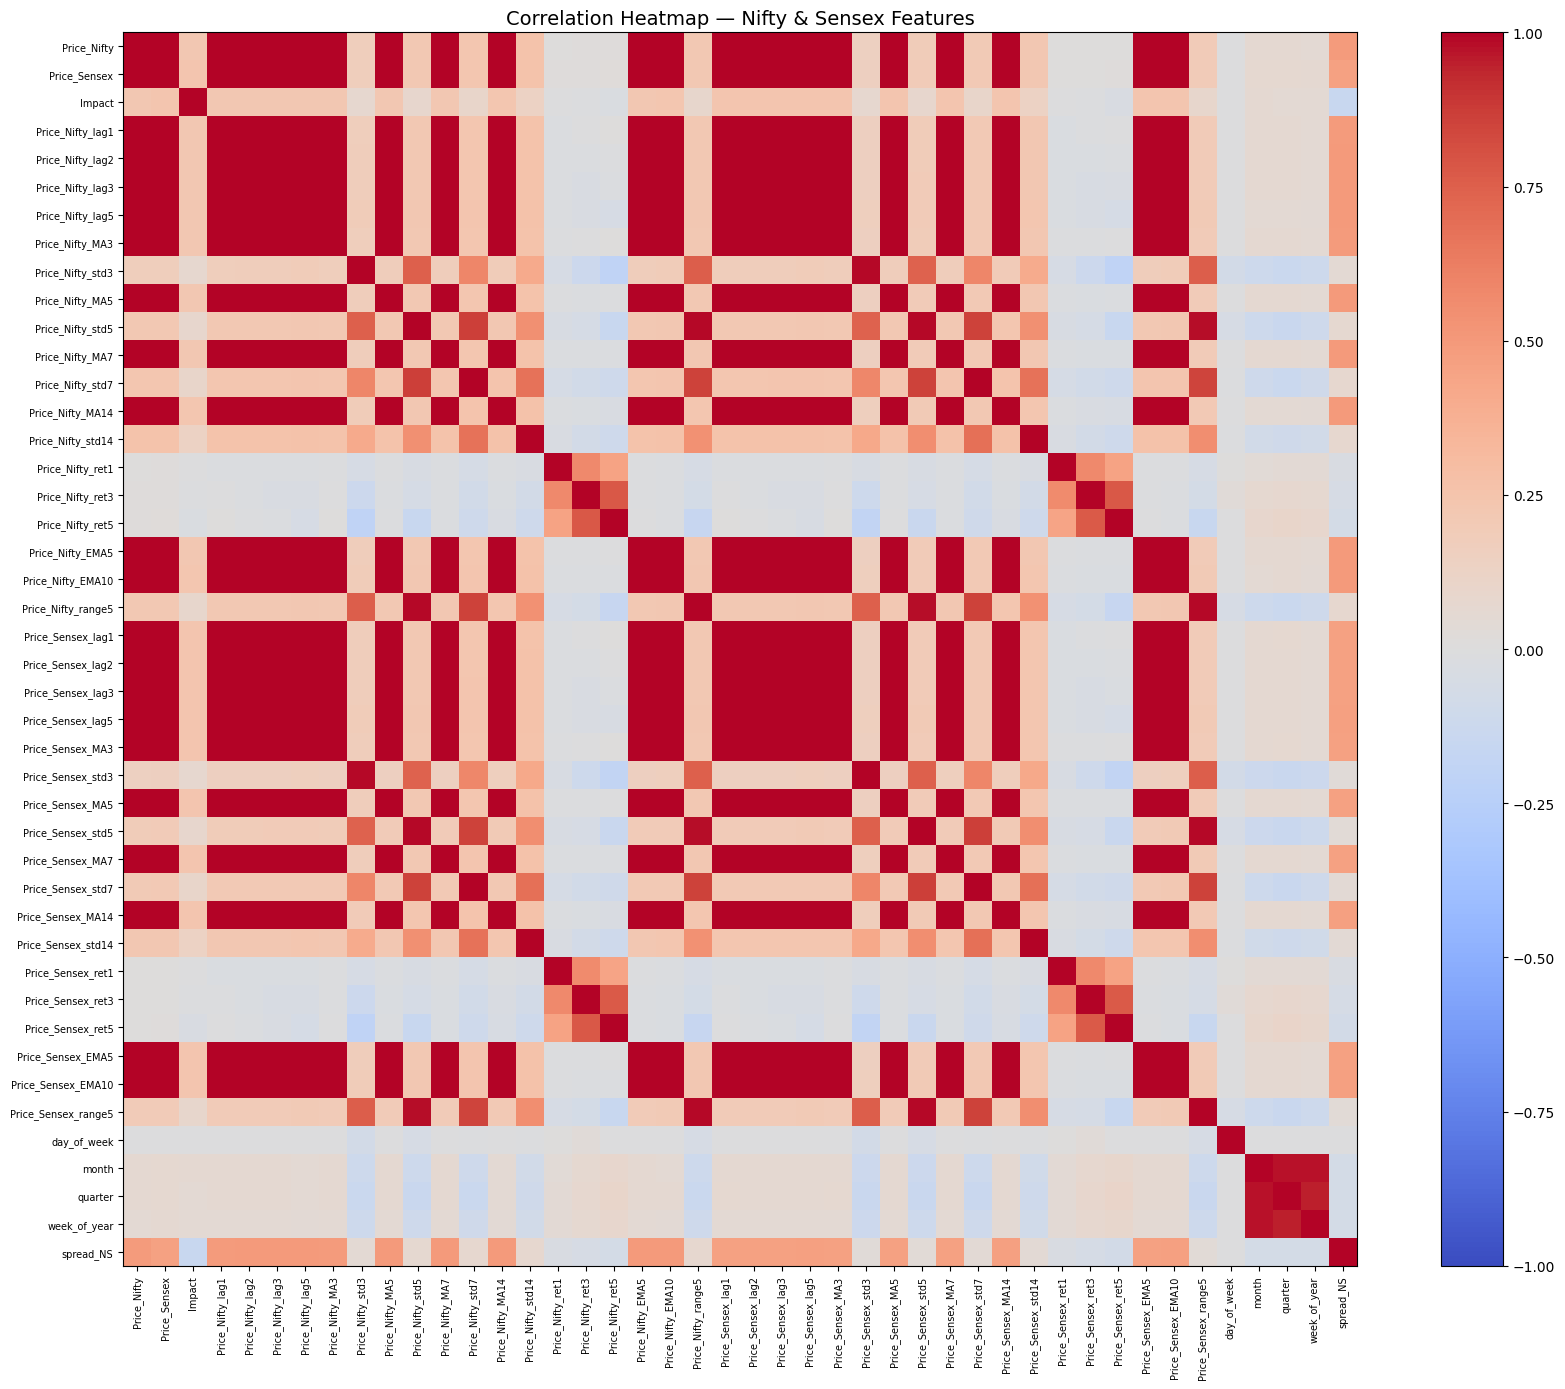

✅ Correlation matrix saved.


In [5]:
# ============================================================
# CELL 5 — Correlation Heatmap
# ============================================================
os.makedirs("/content/models", exist_ok=True)

num_df = df.drop(columns=["Date"])
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(18, 14))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.columns, fontsize=7)
plt.title("Correlation Heatmap — Nifty & Sensex Features", fontsize=14)
plt.tight_layout()
plt.savefig("/content/models/nifty_sensex_correlation_heatmap.png", dpi=120)
plt.show()

corr.to_csv("/content/models/nifty_sensex_correlation_matrix.csv")
print("✅ Correlation matrix saved.")

In [6]:
# ============================================================
# CELL 6 — Prepare Features & Scale
# ============================================================
TARGET_COLS = {"nifty": "Price_Nifty", "sensex": "Price_Sensex"}

FEATURE_COLS = [c for c in df.columns if c not in ["Date"] + list(TARGET_COLS.values())]

X = df[FEATURE_COLS].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

joblib.dump(scaler, "/content/models/nifty_sensex_scaler.pkl")

with open("/content/models/nifty_sensex_feature_cols.json", "w") as f:
    json.dump(FEATURE_COLS, f)

print(f"✅ Scaler saved. Feature matrix shape: {X_scaled.shape}")
print("Features used:", FEATURE_COLS)

✅ Scaler saved. Feature matrix shape: (2129, 42)
Features used: ['Impact', 'Price_Nifty_lag1', 'Price_Nifty_lag2', 'Price_Nifty_lag3', 'Price_Nifty_lag5', 'Price_Nifty_MA3', 'Price_Nifty_std3', 'Price_Nifty_MA5', 'Price_Nifty_std5', 'Price_Nifty_MA7', 'Price_Nifty_std7', 'Price_Nifty_MA14', 'Price_Nifty_std14', 'Price_Nifty_ret1', 'Price_Nifty_ret3', 'Price_Nifty_ret5', 'Price_Nifty_EMA5', 'Price_Nifty_EMA10', 'Price_Nifty_range5', 'Price_Sensex_lag1', 'Price_Sensex_lag2', 'Price_Sensex_lag3', 'Price_Sensex_lag5', 'Price_Sensex_MA3', 'Price_Sensex_std3', 'Price_Sensex_MA5', 'Price_Sensex_std5', 'Price_Sensex_MA7', 'Price_Sensex_std7', 'Price_Sensex_MA14', 'Price_Sensex_std14', 'Price_Sensex_ret1', 'Price_Sensex_ret3', 'Price_Sensex_ret5', 'Price_Sensex_EMA5', 'Price_Sensex_EMA10', 'Price_Sensex_range5', 'day_of_week', 'month', 'quarter', 'week_of_year', 'spread_NS']



  NIFTY — Training on all candidates
  RandomForest   R²: 0.9493  |  MAE: 103  |  MAPE: 0.4064%
  XGBoost        R²: 0.9593  |  MAE: 90  |  MAPE: 0.3527%

  ➡️  Selected: XGBoost  (MAPE 0.3527%)


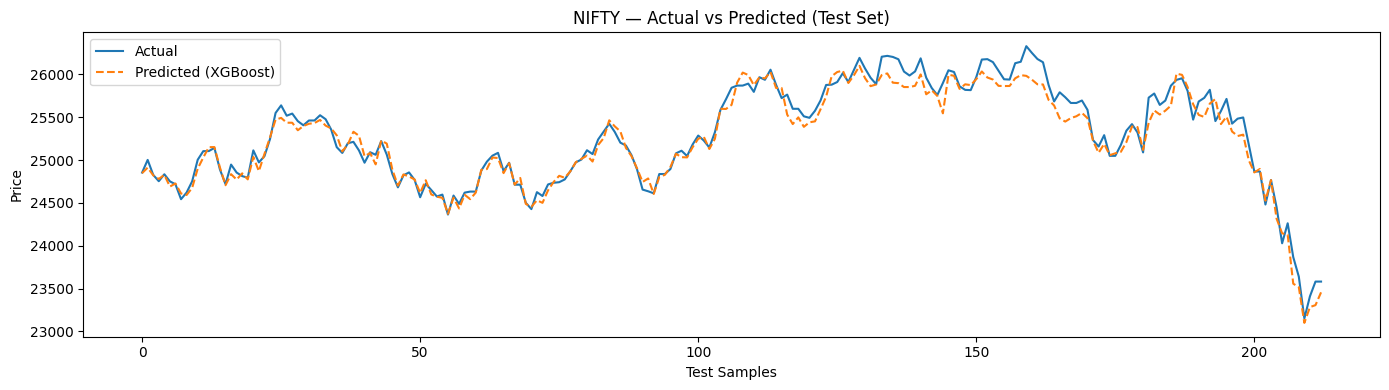


  SENSEX — Training on all candidates
  RandomForest   R²: 0.9352  |  MAE: 366  |  MAPE: 0.4458%
  XGBoost        R²: 0.961  |  MAE: 290  |  MAPE: 0.3506%

  ➡️  Selected: XGBoost  (MAPE 0.3506%)


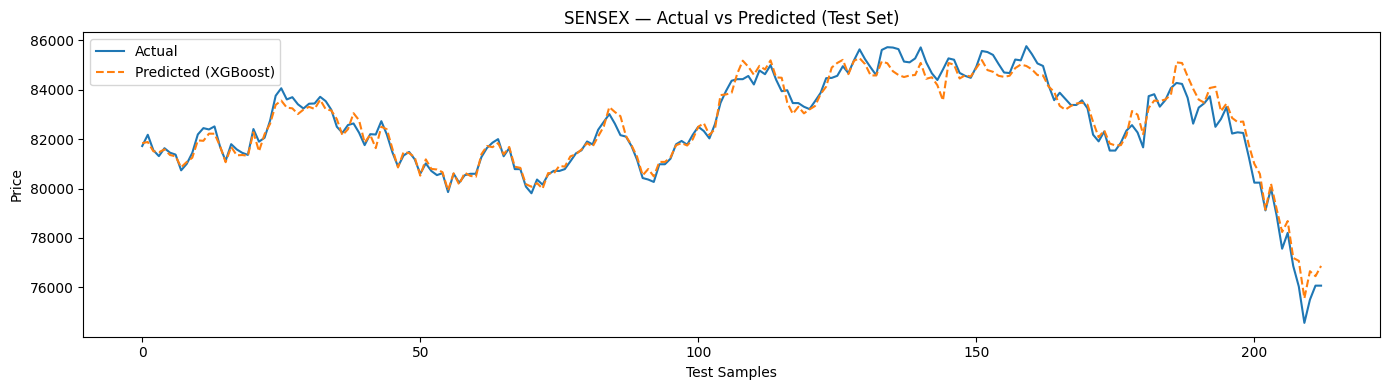


✅ All models trained and evaluated.


In [7]:
# ============================================================
# CELL 7 — Train Models (Nifty & Sensex)
# ============================================================
models       = {}
eval_results = {}

def compute_metrics(y_true, y_pred):
    return {
        "R2":   round(r2_score(y_true, y_pred), 4),
        "MAE":  round(mean_absolute_error(y_true, y_pred), 2),
        "MAPE": round(mean_absolute_percentage_error(y_true, y_pred) * 100, 4)
    }

for name, target_col in TARGET_COLS.items():
    y = df[target_col].values

    # Time-series split — no shuffle
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.10, shuffle=False
    )

    # RandomForest
    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)

    # XGBoost
    xgb = XGBRegressor(
        n_estimators=500,
        learning_rate=0.02,
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.05,
        reg_lambda=1.0,
        random_state=42,
        tree_method="hist",
        verbosity=0
    )
    xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    pred_xgb = xgb.predict(X_test)

    m_rf  = compute_metrics(y_test, pred_rf)
    m_xgb = compute_metrics(y_test, pred_xgb)

    # Pick best by MAPE (lower is better)
    if m_xgb["MAPE"] <= m_rf["MAPE"]:
        best_model, best_name, best_pred, best_m = xgb, "XGBoost", pred_xgb, m_xgb
    else:
        best_model, best_name, best_pred, best_m = rf, "RandomForest", pred_rf, m_rf

    models[name] = best_model
    eval_results[name] = {"best_model": best_name, "rf": m_rf, "xgb": m_xgb}

    print(f"\n{'='*60}")
    print(f"  {name.upper()} — Training on all candidates")
    print(f"{'='*60}")

    for mname, m_val in [("RandomForest", m_rf), ("XGBoost", m_xgb)]:
        print(f"  {mname:<14} R²: {m_val['R2']}  |  MAE: {m_val['MAE']:,.0f}  |  MAPE: {m_val['MAPE']}%")

    print(f"\n  ➡️  Selected: {best_name}  (MAPE {best_m['MAPE']}%)")

    # ── Actual vs Predicted plot ───────────────────────────────────────────────
    plt.figure(figsize=(14, 4))
    plt.plot(y_test,    label="Actual",    linewidth=1.5)
    plt.plot(best_pred, label=f"Predicted ({best_name})", linewidth=1.5, linestyle="--")
    plt.title(f"{name.upper()} — Actual vs Predicted (Test Set)")
    plt.xlabel("Test Samples")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"/content/models/nifty_sensex_{name}_actual_vs_predicted.png", dpi=120)
    plt.show()

print("\n✅ All models trained and evaluated.")

In [8]:
# ============================================================
# CELL 8 — Save Models
# ============================================================
for name, model in models.items():
    path = f"/content/models/nifty_sensex_{name}_model.pkl"
    joblib.dump(model, path)
    print(f"💾 Saved: {path}")

print("✅ All models saved to /content/models/")

💾 Saved: /content/models/nifty_sensex_nifty_model.pkl
💾 Saved: /content/models/nifty_sensex_sensex_model.pkl
✅ All models saved to /content/models/


In [9]:
# ============================================================
# CELL 9 — 🔮 Next-Day Price Prediction
# ============================================================
latest_features = X_scaled[-1:]

# Date of the last row in dataset (today's data) and the next trading day being predicted
today_date     = df["Date"].iloc[-1].strftime("%d %b %Y")
next_day_date  = (df["Date"].iloc[-1] + pd.offsets.BDay(1)).strftime("%d %b %Y")

print("\n" + "="*55)
print(f"  🔮 NEXT-DAY PRICE PREDICTIONS OF {next_day_date}")
print(f"     (Based on data up to {today_date})")
print("="*55)

for name, model in models.items():
    predicted_price = model.predict(latest_features)[0]
    actual_today    = df[TARGET_COLS[name]].iloc[-1]
    change          = predicted_price - actual_today
    pct_change      = (change / actual_today) * 100
    direction       = "▲" if change >= 0 else "▼"

    print(f"""
  {name.upper()}:
    Today's close   : {actual_today:,.2f}
    Predicted close : {predicted_price:,.2f}
    Expected move   : {direction} {abs(change):,.2f}  ({pct_change:+.2f}%)
""")

print("="*55)


  🔮 NEXT-DAY PRICE PREDICTIONS OF 19 Mar 2026
     (Based on data up to 18 Mar 2026)

  NIFTY:
    Today's close   : 23,581.15
    Predicted close : 23,455.36
    Expected move   : ▼ 125.79  (-0.53%)


  SENSEX:
    Today's close   : 76,070.84
    Predicted close : 76,868.44
    Expected move   : ▲ 797.60  (+1.05%)



In [10]:
# ============================================================
# CELL 10 — Export to Backend Folder
# ============================================================
BACKEND_DIR = "/content/backend/models"
os.makedirs(BACKEND_DIR, exist_ok=True)

# Save scaler and feature column list
joblib.dump(scaler, f"{BACKEND_DIR}/nifty_sensex_scaler.pkl")
print("💾 Saved: nifty_sensex_scaler.pkl")

with open(f"{BACKEND_DIR}/nifty_sensex_feature_cols.json", "w") as f:
    json.dump(FEATURE_COLS, f)
print("💾 Saved: nifty_sensex_feature_cols.json")

# Save one model file per index
for name, model in models.items():
    path = f"{BACKEND_DIR}/nifty_sensex_{name}_model.pkl"
    joblib.dump(model, path)
    print(f"💾 Saved: nifty_sensex_{name}_model.pkl")

print(f"\n🚀 All files exported to {BACKEND_DIR}")

💾 Saved: nifty_sensex_scaler.pkl
💾 Saved: nifty_sensex_feature_cols.json
💾 Saved: nifty_sensex_nifty_model.pkl
💾 Saved: nifty_sensex_sensex_model.pkl

🚀 All files exported to /content/backend/models


In [11]:
# ============================================================
# CELL 11 — Retraining Pipeline (run anytime with new data)
# ============================================================
def retrain_pipeline(data_path="/content/metal_prices_impact.csv"):
    """
    Retrains Nifty & Sensex models on the latest CSV.
    Saves updated models + scaler to /content/backend/models/.
    """
    print("🚀 Retraining started...")

    df = pd.read_csv(data_path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.drop_duplicates(subset="Date").sort_values("Date").reset_index(drop=True)

    for col in ["Price_Nifty", "Price_Sensex"]:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", "", regex=False), errors="coerce"
        )

    keep = ["Date", "Price_Nifty", "Price_Sensex"]
    if "Impact" in df.columns:
        keep.append("Impact")
    df = df[keep].ffill().bfill()

    for col in ["Price_Nifty", "Price_Sensex"]:
        for lag in [1, 2, 3, 5]:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)
        for window in [3, 5, 7, 14]:
            df[f"{col}_MA{window}"]  = df[col].rolling(window).mean()
            df[f"{col}_std{window}"] = df[col].rolling(window).std()
        df[f"{col}_ret1"]   = df[col].pct_change(1)
        df[f"{col}_ret3"]   = df[col].pct_change(3)
        df[f"{col}_ret5"]   = df[col].pct_change(5)
        df[f"{col}_EMA5"]   = df[col].ewm(span=5,  adjust=False).mean()
        df[f"{col}_EMA10"]  = df[col].ewm(span=10, adjust=False).mean()
        df[f"{col}_range5"] = df[col].rolling(5).max() - df[col].rolling(5).min()

    df["day_of_week"]  = df["Date"].dt.dayofweek
    df["month"]        = df["Date"].dt.month
    df["quarter"]      = df["Date"].dt.quarter
    df["week_of_year"] = df["Date"].dt.isocalendar().week.astype(int)
    df["spread_NS"]    = df["Price_Nifty"] - (df["Price_Sensex"] / 3.3)
    df = df.dropna().reset_index(drop=True)

    TARGET_COLS  = {"nifty": "Price_Nifty", "sensex": "Price_Sensex"}
    feature_cols = [c for c in df.columns if c not in ["Date"] + list(TARGET_COLS.values())]
    X = df[feature_cols].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    os.makedirs("/content/backend/models", exist_ok=True)

    # Save scaler and feature column list
    joblib.dump(scaler, "/content/backend/models/nifty_sensex_scaler.pkl")
    with open("/content/backend/models/nifty_sensex_feature_cols.json", "w") as f:
        json.dump(feature_cols, f)

    split = int(len(X_scaled) * 0.9)
    X_train, X_test = X_scaled[:split], X_scaled[split:]

    for name, target_col in TARGET_COLS.items():
        y = df[target_col].values
        y_train, y_test = y[:split], y[split:]

        rf = RandomForestRegressor(
            n_estimators=500, max_depth=None, min_samples_split=2,
            min_samples_leaf=1, max_features="sqrt", random_state=42, n_jobs=-1
        )
        rf.fit(X_train, y_train)

        xgb = XGBRegressor(
            n_estimators=500, learning_rate=0.02, max_depth=6,
            subsample=0.85, colsample_bytree=0.85, random_state=42,
            tree_method="hist", verbosity=0
        )
        xgb.fit(X_train, y_train)

        mape_rf  = mean_absolute_percentage_error(y_test, rf.predict(X_test))
        mape_xgb = mean_absolute_percentage_error(y_test, xgb.predict(X_test))

        best      = xgb if mape_xgb <= mape_rf else rf
        best_name = "XGBoost" if mape_xgb <= mape_rf else "RandomForest"

        # Save only the best model
        joblib.dump(best, f"/content/backend/models/nifty_sensex_{name}_model.pkl")
        print(f"✅ {name.upper()} retrained — Selected: {best_name}  (MAPE {min(mape_rf, mape_xgb)*100:.4f}%)")

    print("\n🎉 Retraining complete — all models & scaler updated!")